## Project Goal

Predict whether a customer will subscribe to a term deposit using a Decision Tree Classifier.

Main concepts covered:

- Gini impurity
- Entropy and Information Gain
- Overfitting
- Hyperparameter tuning
- Cost-complexity pruning
- Feature importance
- Decision tree visualisation

### Dataset Overview

This project uses the Bank Marketing dataset from the UCI Machine Learning Repository. The dataset is based on direct marketing campaigns conducted by a Portuguese banking institution through phone calls. The main goal is to predict whether a customer will subscribe to a term deposit.

The dataset contains 45,211 customer records and 17 columns. There are 16 input features and one target variable, `y`. The target variable has two possible outcomes: `yes`, meaning the customer subscribed to a term deposit, and `no`, meaning the customer did not subscribe. This makes the problem a binary classification task.

The input variables include customer personal information such as age, job, marital status and education; financial information such as account balance, housing loan and personal loan status; current campaign information such as contact type, month, day and number of campaign contacts; and previous campaign information such as previous contact count and previous campaign outcome.

This dataset is suitable for Decision Tree Classification because the model can create clear rule-based decisions using both categorical and numerical variables. It also allows comparison of Gini impurity and Entropy, analysis of overfitting, hyperparameter tuning and pruning.

In [1]:
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)


In [2]:
# Loading the dataset
# The code below downloads the UCI Bank Marketing dataset if the CSV file is not already available.

DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

dataset_url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
outer_zip_path = DATA_DIR / "bank_marketing.zip"
inner_zip_path = DATA_DIR / "bank.zip"
csv_path = DATA_DIR / "bank-full.csv"

if not csv_path.exists():
    print("Downloading dataset from UCI...")
    urllib.request.urlretrieve(dataset_url, outer_zip_path)

    with zipfile.ZipFile(outer_zip_path, "r") as outer_zip:
        outer_zip.extractall(DATA_DIR)

    with zipfile.ZipFile(inner_zip_path, "r") as inner_zip:
        inner_zip.extractall(DATA_DIR)

df = pd.read_csv(csv_path, sep=";")

print(df.head())
print(df.info())
print(df.describe())


   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #

## data exploration

In [3]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [4]:
# checking if there are any missing values.
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [5]:
# checking if there are any duplicated rows

df.duplicated().sum()

0

In [6]:
# checking the target variable distribution.
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [7]:
# checking target variable distribution as percentages.
df['y'].value_counts(normalize=True) * 100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

The target variable is imbalanced. Most customers did not subscribe to a term deposit, while only a smaller percentage subscribed. Because of this, accuracy alone may not be enough to judge the model. Precision, recall, F1-score and ROC-AUC should also be checked.

## Exploratory Data Analysis

### Target variable count plot

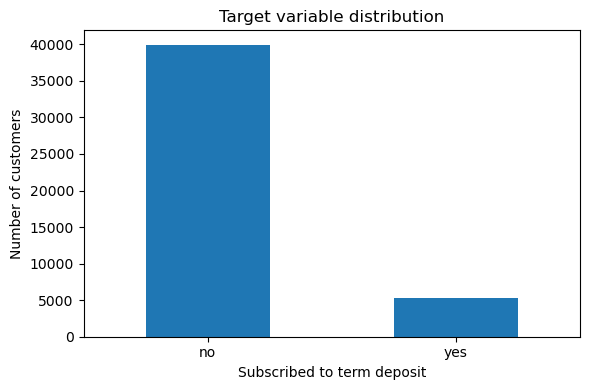

In [8]:
# visualising the number of customers who subscribed and did not subscribe.
plt.figure(figsize=(6,4))
df['y'].value_counts().plot(kind='bar')

plt.title('Target variable distribution')
plt.xlabel('Subscribed to term deposit')
plt.ylabel('Number of customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Age distribution

c:\Users\M.SRIMANREDDY\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


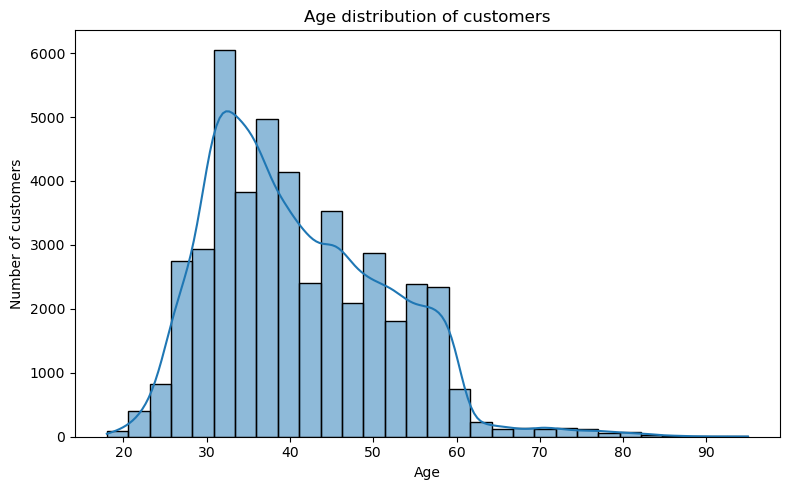

In [9]:
# checking the age distribution of customers.
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age distribution of customers')
plt.xlabel('Age')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()


### Subscription by job type

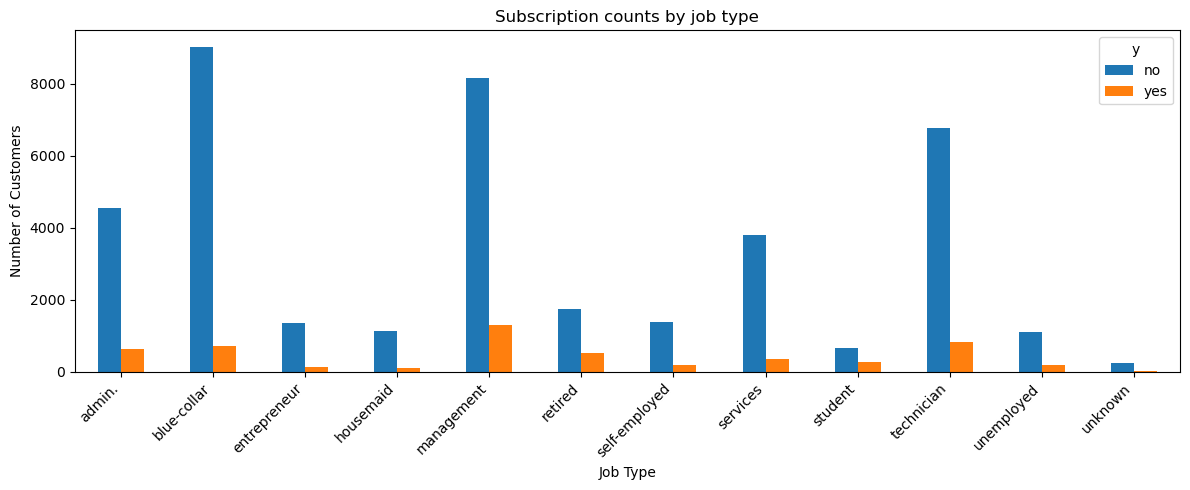

In [10]:
#  checking how subscription counts vary by job type.
job_subscription = pd.crosstab(df["job"], df["y"])
job_subscription.plot(kind="bar", figsize=(12, 5))
plt.title("Subscription counts by job type")
plt.xlabel("Job Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45,ha = 'right')
plt.tight_layout()
plt.show()

In [11]:
job_subscription 

y,no,yes
job,,
admin.,4540,631
blue-collar,9024,708
entrepreneur,1364,123
housemaid,1131,109
management,8157,1301
retired,1748,516
self-employed,1392,187
services,3785,369
student,669,269


### Subscription by marital status

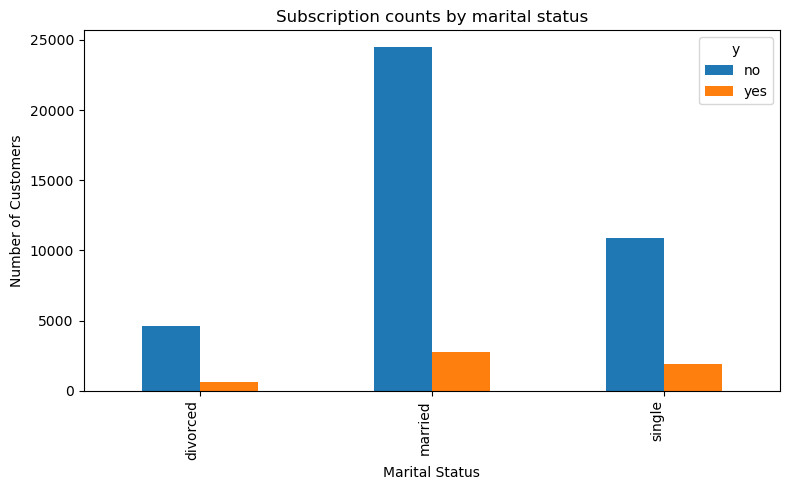

In [12]:
# checking subscription outcome based on marital status.
maritial_subscription = pd.crosstab(df["marital"], df["y"])
maritial_subscription.plot(kind="bar", figsize=(8, 5))
plt.title("Subscription counts by marital status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=90,ha = 'right')
plt.tight_layout()
plt.show()

### Correlation heatmap for numerical variables

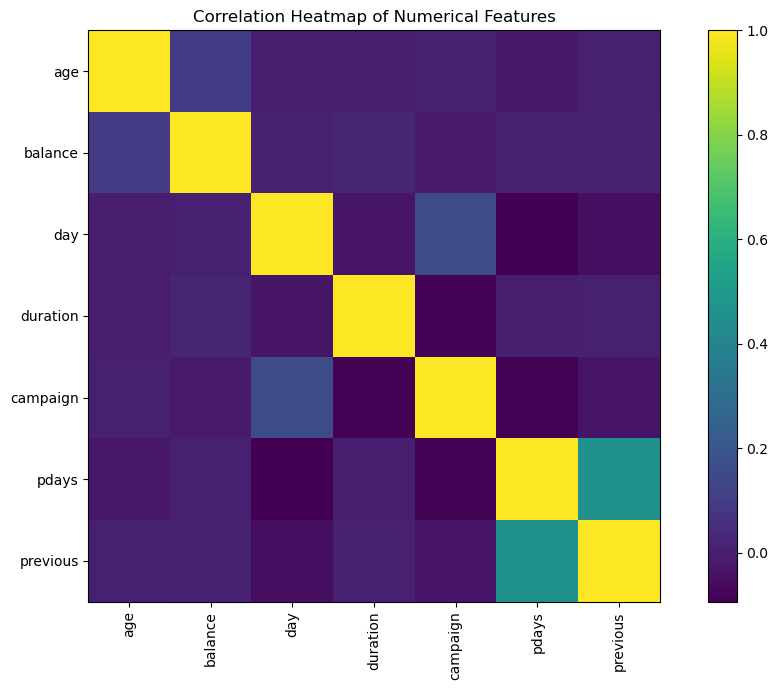

In [13]:
# I am checking correlation between numerical variables.

numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 7))
plt.imshow(correlation_matrix)
plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


In [14]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [15]:
# checking subscription rate by housing loan status.
pd.crosstab(df['housing'], df['y'], normalize='index') *100

y,no,yes
housing,,
no,83.297645,16.702355
yes,92.300040,7.699960


In [16]:
# checking subscription rate by personal loan status.
pd.crosstab(df['loan'], df['y'], normalize='index') *100

y,no,yes
loan,,
no,87.344273,12.655727
yes,93.318609,6.681391


In [17]:
# checking subscription rate by default status.
pd.crosstab(df['default'], df['y'], normalize='index') *100

y,no,yes
default,,
no,88.203892,11.796108
yes,93.619632,6.380368


In [18]:
# creating a simple function to compare subscription rates for yes/no financial features.

financial_features = ["housing", "loan", "default"]

for feature in financial_features:
    print(f"\nSubscription percentage by {feature}:")
    display(pd.crosstab(df[feature], df["y"], normalize="index") * 100)


Subscription percentage by housing:


y,no,yes
housing,,
no,83.297645,16.702355
yes,92.300040,7.699960



Subscription percentage by loan:


y,no,yes
loan,,
no,87.344273,12.655727
yes,93.318609,6.681391



Subscription percentage by default:


y,no,yes
default,,
no,88.203892,11.796108
yes,93.619632,6.380368


Subscription rates by housing:
y               no        yes
housing                      
no       83.297645  16.702355
yes      92.300040   7.699960



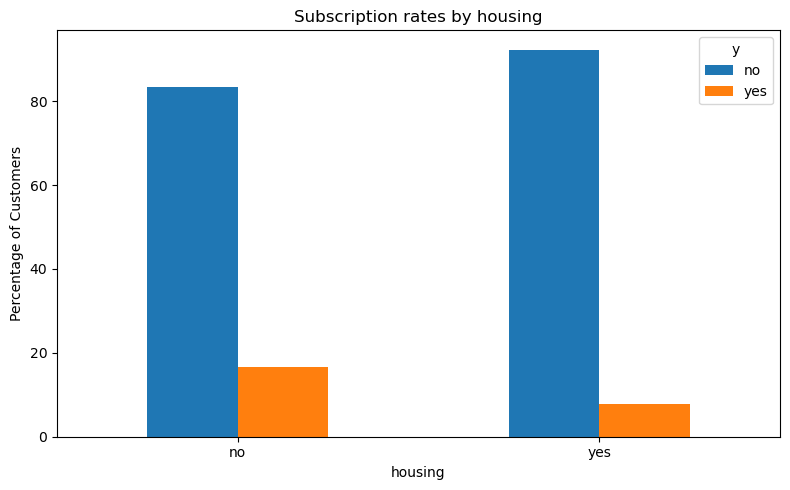

Subscription rates by loan:
y            no        yes
loan                      
no    87.344273  12.655727
yes   93.318609   6.681391



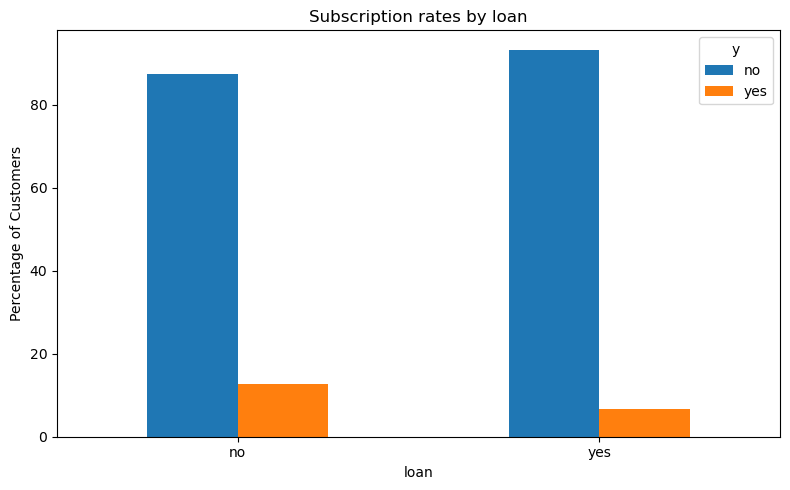

Subscription rates by default:
y               no        yes
default                      
no       88.203892  11.796108
yes      93.619632   6.380368



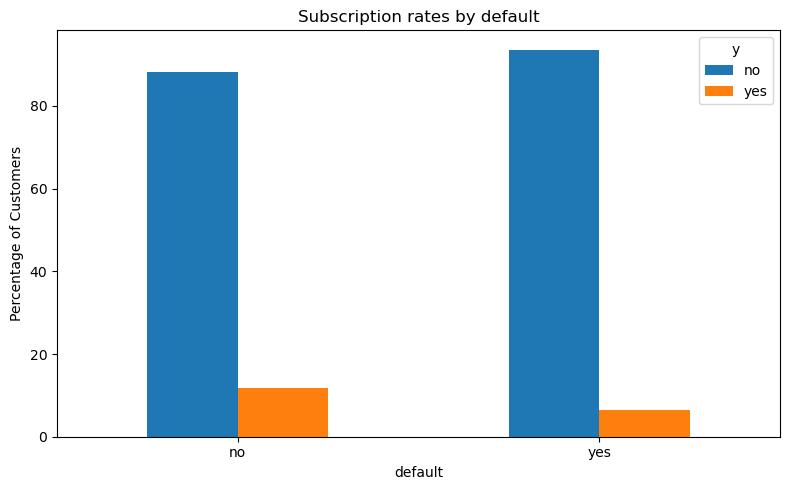

In [19]:
# creating a plots to compare subscription rates for yes/no financial features.
def compare_subscription_rates(feature):
    subscription_rates = pd.crosstab(df[feature], df['y'], normalize='index') * 100
    print(f"Subscription rates by {feature}:\n{subscription_rates}\n")
    subscription_rates.plot(kind='bar', figsize=(8,5))
    plt.title(f'Subscription rates by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Percentage of Customers')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
financial_features = ["housing", "loan", "default"]
for feature in financial_features:
    compare_subscription_rates(feature)

The subscription rate differs clearly across financial obligation variables.

For housing loans, customers without a housing loan had a subscription rate of about 16.70%, while customers with a housing loan had a much lower subscription rate of about 7.70%. This suggests that customers with housing loans may be less likely to subscribe to a term deposit.

For personal loans, customers without a personal loan had a subscription rate of about 12.66%, compared with only 6.68% for customers with a personal loan. This indicates that customers who already have personal loan obligations may be less likely to commit money to a term deposit.

For credit default, customers without default history had a subscription rate of about 11.80%, while customers with default history had a subscription rate of about 6.38%. This pattern suggests that default status may also be related to subscription behaviour, although this result should be interpreted carefully because the number of customers with default history is relatively small.

Overall, these results suggest that financial obligation variables such as housing loan, personal loan and default status may be useful predictors for the Decision Tree model.

# Prepare data for modelling

In [20]:
# making a copy of the dataset before preprocessing.
model_df = df.copy()
# converting the target variable into binary format.
model_df['y'] = model_df['y'].map({'yes':1, 'no':0})
# The duration column is strongly related to the target because it records call duration.
# In a real marketing prediction problem, duration would not be known before the call.
# So I am dropping it to make the model more realistic.
model_df = model_df.drop("duration", axis=1)

In [21]:
#  separating input features and target variable. 
X = model_df.drop('y', axis = 1)
y = model_df['y']

In [22]:
# identifying categorical and numerical columns
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
numerical_columns = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numerical columns:
['age', 'balance', 'day', 'campaign', 'pdays', 'previous']


## Train-test split

In [23]:
# splitting the data into training and testing sets.
# stratify=y keeps the same target class ratio in both train and test sets.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples") 

Training set size: 36168 samples
Testing set size: 9043 samples


# Preprocessing pipeline

In [24]:
#  one-hot encoding for categorical columns.
# Decision Trees do not require feature scaling, so numerical columns are passed as they are.

preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns),
        ('numerical', 'passthrough', numerical_columns)
    ]
)

### Baseline Decision Tree using Gini

In [25]:
# building the first Decision Tree model using Gini impurity.
gini_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(criterion='gini', random_state=42))
    ])
gini_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome']),
                                                 ('numerical', 'passthrough',
                                                  ['age', 'balance', 'day',
                                                   'campaign', 'pdays',
                                                   'previous'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [26]:
# evaluating the Gini model.
# I am extracting the predicted probabilities for the positive class (Class 1: 'Yes').
# Instead of hard predictions, this gives the raw percentage chance for each customer,
# which is required to calculate the ROC-AUC score and rank customers by subscription likelihood.
gini_train_pred = gini_model.predict(X_train)
gini_test_pred = gini_model.predict(X_test)
gini_test_prob = gini_model.predict_proba(X_test)[:, 1]

print("Gini Decision Tree")
print("Training Accuracy:", accuracy_score(y_train, gini_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, gini_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, gini_test_prob))

print("\nClassification Report:")
print(classification_report(y_test, gini_test_pred))

Gini Decision Tree
Training Accuracy: 1.0
Testing Accuracy: 0.8329094327103838
ROC-AUC: 0.6126648145802681

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      7985
           1       0.30      0.33      0.31      1058

    accuracy                           0.83      9043
   macro avg       0.61      0.61      0.61      9043
weighted avg       0.84      0.83      0.84      9043



### Baseline Gini Decision Tree Results

The baseline Decision Tree using Gini impurity achieved a training accuracy of 1.00 and a testing accuracy of about 0.823. The perfect training accuracy suggests that the model has overfitted the training data by growing too deep and memorising patterns.

Although the testing accuracy appears reasonably high, the classification report shows that the model performs much better for the majority class than for the minority class. For class 0, which represents customers who did not subscribe, the model achieved high precision, recall and F1-score. However, for class 1, which represents customers who subscribed, the precision was only 0.30 and recall was only 0.33.

This means the model is missing many actual subscribers. Since the business goal is to identify customers who are likely to subscribe, accuracy alone is not enough. Metrics such as recall, F1-score and ROC-AUC are more useful for judging the model.

The ROC-AUC score of about 0.613 shows that the baseline model has only moderate ability to separate subscribers from non-subscribers. Therefore, hyperparameter tuning and pruning are needed to reduce overfitting and improve generalisation.

### Baseline Decision Tree using Entropy

In [27]:
# building another Decision Tree model using Entropy.
# Entropy is related to Information Gain.
entropy_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(criterion='entropy', random_state=42))
    ]
)
entropy_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome']),
                                                 ('numerical', 'passthrough',
                                                  ['age', 'balance', 'day',
                                                   'campaign', 'pdays',
                                                   'previous'])])),
                ('classifier',
                 DecisionTreeClassifier(criterion='entropy', random_state=42))])

In [28]:
# evaluating the Entropy model.

entropy_train_pred = entropy_model.predict(X_train)
entropy_test_pred = entropy_model.predict(X_test)
entropy_test_prob = entropy_model.predict_proba(X_test)[:,1]


print("Entropy Decision Tree")
print("Training Accuracy:", accuracy_score(y_train, entropy_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, entropy_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, entropy_test_prob))

print("\nClassification Report:")
print(classification_report(y_test, entropy_test_pred))

Entropy Decision Tree
Training Accuracy: 1.0
Testing Accuracy: 0.8305871945150946
ROC-AUC: 0.6080700699444729

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      7985
           1       0.29      0.32      0.30      1058

    accuracy                           0.83      9043
   macro avg       0.60      0.61      0.60      9043
weighted avg       0.84      0.83      0.83      9043



In [30]:
# comparing the two baseline models.
comparison = pd.DataFrame({
    'Model': ['Gini Decision Tree', 'Entropy Decision Tree'],
    'Training Accuracy': [accuracy_score(y_train, gini_train_pred), accuracy_score(y_train, entropy_train_pred)],
    'Testing Accuracy': [accuracy_score(y_test, gini_test_pred), accuracy_score(y_test, entropy_test_pred)],
    'ROC-AUC': [roc_auc_score(y_test, gini_test_prob), roc_auc_score(y_test, entropy_test_prob)]    
})
comparison

,Model,Training Accuracy,Testing Accuracy,ROC-AUC
0,Gini Decision Tree,1.0,0.832909,0.612665
1,Entropy Decision Tree,1.0,0.830587,0.608070


### Baseline Entropy Decision Tree Results

The baseline Decision Tree using Entropy achieved a training accuracy of 1.00 and a testing accuracy of about 0.831. The perfect training accuracy indicates that the model has overfitted the training data by growing too complex.

Although the testing accuracy is slightly higher than the Gini-based tree, the ROC-AUC score is about 0.608, which shows only moderate separation between subscribers and non-subscribers.

The classification report shows that the model performs well for class 0, which represents customers who did not subscribe. However, the performance for class 1 is weak, with precision of 0.29, recall of 0.32 and F1-score of 0.30. This means the model still misses many customers who actually subscribed.

Overall, the Entropy-based Decision Tree performs similarly to the Gini-based tree. Both models show overfitting and weak performance on the minority class. Therefore, hyperparameter tuning and pruning are required to control tree complexity and improve generalisation.

### Hyperparameter tuning

In [40]:
tuned_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
    ]
)

param_grid = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [3, 4, 5, 6, 7, 8],
    "classifier__min_samples_split": [20, 50, 100, 200],
    "classifier__min_samples_leaf": [10, 20, 50, 100],
    "classifier__ccp_alpha": [0.0, 0.0005, 0.001, 0.005, 0.01]
}

grid_search = GridSearchCV(
    estimator=tuned_pipeline,
    param_grid=param_grid,
    scoring = 'f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 960 candidates, totalling 4800 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['job',
                                                                          'marital',
                                                                          'education',
                                                                          'default',
                                                                          'housing',
                                                                          'loan',
                                                                          'contact',
                                                                          'month',
                                                                          'poutcome']),
                                                                        ('numerical',
                                                                         'passthrough',
                                                                         ['age',
                                                                          'balance',
                                                                          'day',
                                                                          'campaign',
                                                                          'pdays',
                                                                          'previous'])])),
                                       ('classifier',
                                        DecisionTreeClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__ccp_alpha': [0.0, 0.0005, 0.001, 0.005,
                                                   0.01],
                         'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [3, 4, 5, 6, 7, 8],
                         'classifier__min_samples_leaf': [10, 20, 50, 100],
                         'classifier__min_samples_split': [20, 50, 100, 200]},
             scoring='f1', verbose=1)

In [41]:
# I am checking the best parameters selected by GridSearchCV.

grid_search.best_params_

{'classifier__ccp_alpha': 0.001,
 'classifier__criterion': 'gini',
 'classifier__max_depth': 7,
 'classifier__min_samples_leaf': 10,
 'classifier__min_samples_split': 20}

In [42]:
# I am evaluating the best tuned model.

best_model = grid_search.best_estimator_

tuned_train_pred = best_model.predict(X_train)
tuned_test_pred = best_model.predict(X_test)
tuned_test_prob = best_model.predict_proba(X_test)[:, 1]

print("Tuned Decision Tree")
print("Training Accuracy:", accuracy_score(y_train, tuned_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, tuned_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, tuned_test_prob))

print("\nClassification Report:")
print(classification_report(y_test, tuned_test_pred))

Tuned Decision Tree
Training Accuracy: 0.8398031408980314
Testing Accuracy: 0.8370009952449409
ROC-AUC: 0.7558120554489574

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.87      0.90      7985
           1       0.37      0.55      0.44      1058

    accuracy                           0.84      9043
   macro avg       0.65      0.71      0.67      9043
weighted avg       0.87      0.84      0.85      9043



### Improved Tuned Decision Tree Results

After applying stronger hyperparameter tuning, the Decision Tree achieved a training accuracy of about 0.840 and a testing accuracy of about 0.837. The training and testing scores are very close, which suggests that the model is no longer heavily overfitting the training data.

The ROC-AUC score improved to about 0.756, which is much better than the baseline models. This shows that the tuned model has a stronger ability to separate customers who subscribed from those who did not.

The biggest improvement is seen in class 1, which represents customers who subscribed to the term deposit. The recall for class 1 increased to 0.55, meaning the model can now identify about 55% of actual subscribers. This is a clear improvement compared with the earlier baseline models, where class 1 recall was only around 0.31 to 0.33.

However, the precision for class 1 is still relatively low at 0.37. This means the model also produces some false positives when predicting subscribers. In a marketing campaign, this may still be acceptable because identifying more potential subscribers can be more valuable than missing them.

Overall, the tuned Decision Tree provides a better balance between generalisation and subscriber detection. It reduces overfitting and improves the model's usefulness for the business problem.


### visualising the confusion matrix for the tuned model.


FileNotFoundError: [Errno 2] No such file or directory: 'images/confusion_matrix.png'

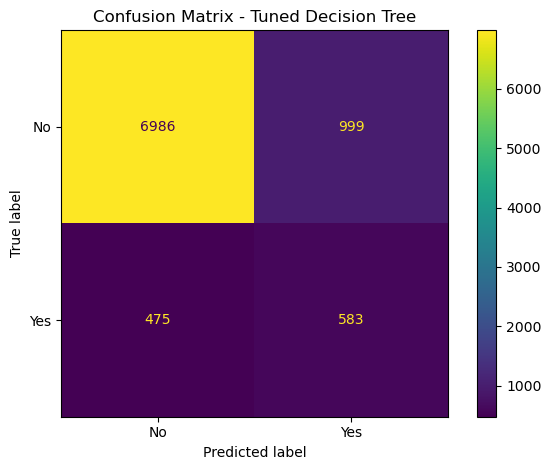

In [ ]:
from pathlib import Path


cm = confusion_matrix(y_test, tuned_test_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

display.plot()
plt.title("Confusion Matrix - Tuned Decision Tree")
Path("images").mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig("images/confusion_matrix.png", dpi=300)
plt.show()